In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dir = 'drive/MyDrive/PCD MB/TUGAS/TUGAS AKHIR/Chili_Plant_Disease/'

train_dir = dir+'train'
val_dir = dir+'val'
test_dir = dir+'test'

In [4]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=180,
    zoom_range=0.2
)
val_test_gen = ImageDataGenerator(rescale=1./255)

In [5]:
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(100,100),
    class_mode='categorical',
    shuffle=True
)

val_data = val_test_gen.flow_from_directory(
    val_dir,
    target_size=(100,100),
    class_mode='categorical',
    shuffle=True
)

test_data = val_test_gen.flow_from_directory(
    test_dir,
    target_size=(100,100),
    class_mode='categorical',
    shuffle=False
)

Found 400 images belonging to 5 classes.
Found 50 images belonging to 5 classes.
Found 50 images belonging to 5 classes.


In [6]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(100, 100, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

model.summary()

model.compile(loss = 'categorical_crossentropy', optimizer=RMSprop(learning_rate=0.001), metrics=['accuracy'])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 98, 16)        448       
                                                                 
 batch_normalization (Batch  (None, 98, 98, 16)        64        
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 49, 49, 16)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 49, 49, 16)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 47, 47, 32)        4640      
                                                                 
 batch_normalization_1 (Bat  (None, 47, 47, 32)        1

In [7]:
history = model.fit(
            train_data,
            validation_data=val_data,
            epochs=500)

Epoch 1/500
13/13 [==============================] - 157s 11s/step - loss: 2.3374 - accuracy: 0.2600 - val_loss: 1.6028 - val_accuracy: 0.2600
Epoch 2/500
13/13 [==============================] - 2s 157ms/step - loss: 2.1380 - accuracy: 0.3150 - val_loss: 1.6576 - val_accuracy: 0.2000
Epoch 3/500
13/13 [==============================] - 2s 154ms/step - loss: 1.8592 - accuracy: 0.3225 - val_loss: 1.7738 - val_accuracy: 0.2000
Epoch 4/500
13/13 [==============================] - 2s 152ms/step - loss: 1.7855 - accuracy: 0.3425 - val_loss: 1.8452 - val_accuracy: 0.2000
Epoch 5/500
13/13 [==============================] - 2s 161ms/step - loss: 1.5454 - accuracy: 0.4125 - val_loss: 1.9323 - val_accuracy: 0.2000
Epoch 6/500
13/13 [==============================] - 3s 207ms/step - loss: 1.6640 - accuracy: 0.3425 - val_loss: 2.0190 - val_accuracy: 0.2000
Epoch 7/500
13/13 [==============================] - 2s 163ms/step - loss: 1.5161 - accuracy: 0.4025 - val_loss: 2.1425 - val_accuracy: 0.2000

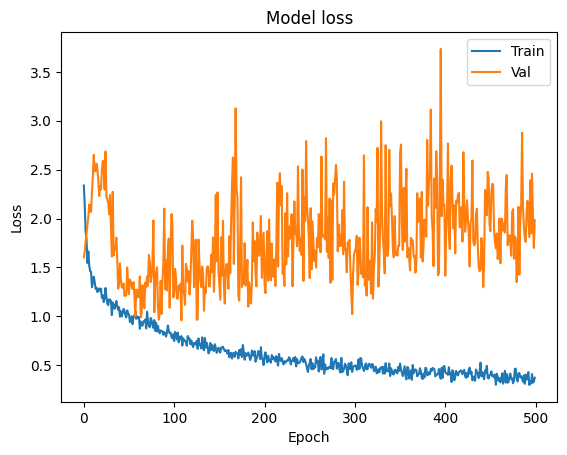

<Figure size 640x480 with 0 Axes>

In [8]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
plt.savefig(dir+'chart_loss.png')

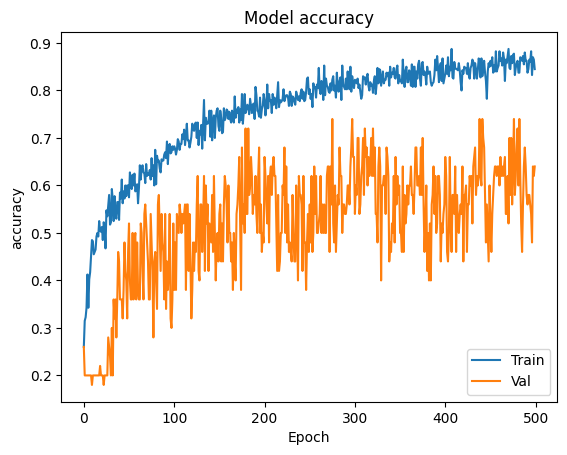

<Figure size 640x480 with 0 Axes>

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()
plt.savefig(dir+'chart_accuracy.png')

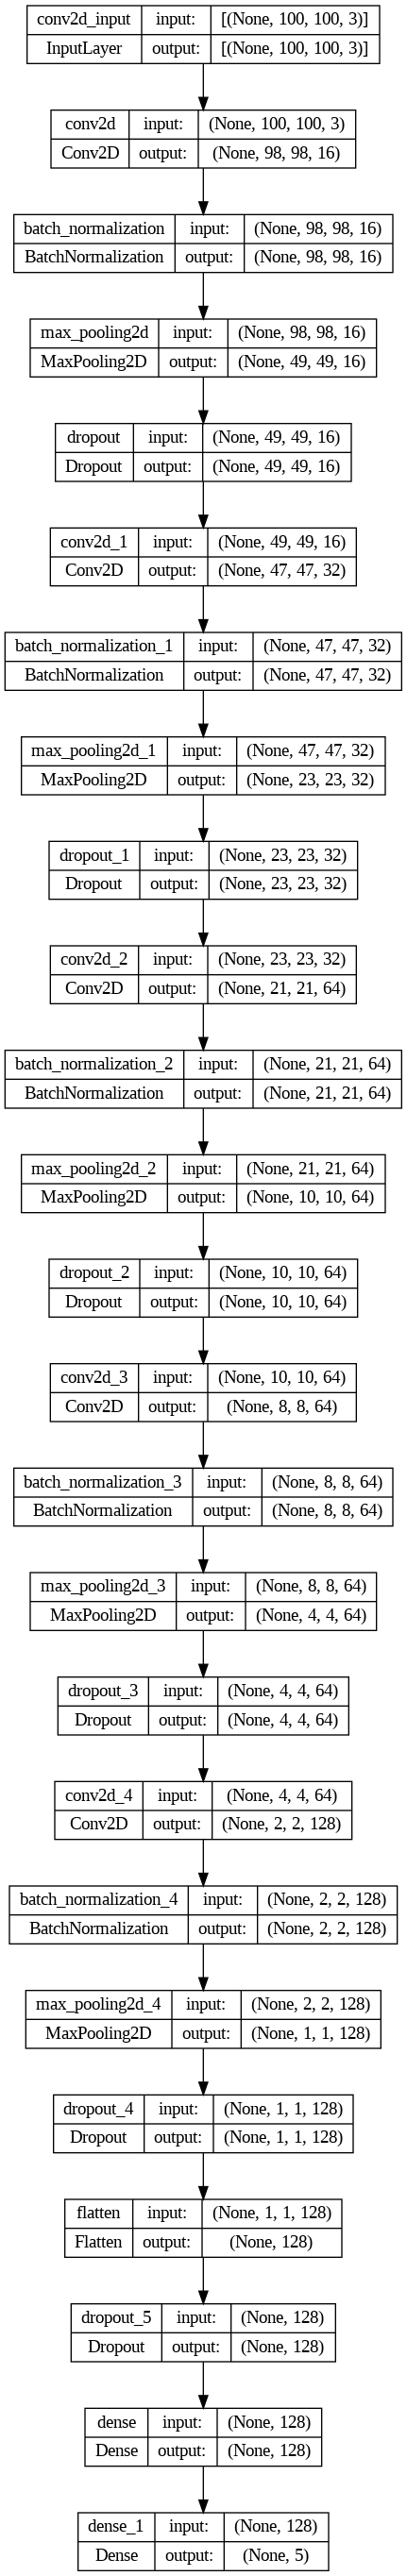

In [10]:
dot_img_file = dir+'model_1.png'
tf.keras.utils.plot_model(model, to_file=dot_img_file, show_shapes=True)

In [11]:
#save architecture as json and weight as h5
model_json = model.to_json()
with open(dir+"model.json", "w") as json_file:
    json_file.write(model_json)
# serialize weights to HDF5
model.save_weights(dir+"model.h5")

In [12]:
tf.saved_model.save(model, dir+"tflite")

In [13]:
model.save(dir+"model/disease.h5")
model.save(dir+"model/disease")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [14]:
# Use the flow_from_directory() method to retrieve the classes
class_names = list(train_gen.flow_from_directory(train_dir).class_indices.keys())

# Print the classes
print(class_names)

Found 400 images belonging to 5 classes.
['healthy', 'leaf curl', 'leaf spot', 'whitefly', 'yellowish']


In [21]:
import numpy as np
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import_model = tf.keras.models.load_model(dir+'model/disease.h5')
uploaded = files.upload()

for fn in uploaded.keys():

  # predicting images
  path = '/content/' + fn
  img = load_img(path, target_size=(100, 100))
  x = img_to_array(img)
  x /= 255
  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  classes = import_model.predict(images, batch_size=10)
    # Assuming you have a list of label names
  label_names = ['healthy', 'leaf curl', 'leaf spot', 'whitefly', 'yellowish']   # Replace with your actual label names

  # Get the index of the predicted label
  predicted_label_index = np.argmax(classes)

  # Get the predicted label name
  predicted_label_name = label_names[predicted_label_index]

  print("Predicted label:", predicted_label_name)
  print(classes)

Saving gejala-virus-kuning-1.jpg to gejala-virus-kuning-1 (1).jpg
1/1 [==============================] - 0s 200ms/step
Predicted label: leaf curl
[[8.5279755e-03 9.5458221e-01 1.5492735e-05 3.1535447e-02 5.3388597e-03]]


In [16]:
loaded = tf.saved_model.load(dir+"tflite")
print(list(loaded.signatures.keys()))
infer = loaded.signatures["serving_default"]
print(infer.structured_input_signature)
print(infer.structured_outputs)

['serving_default']
((), {'conv2d_input': TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='conv2d_input')})
{'dense_1': TensorSpec(shape=(None, 5), dtype=tf.float32, name='dense_1')}


In [17]:
converter = tf.lite.TFLiteConverter.from_saved_model(dir+"tflite")

In [18]:
converter.optimizations = [tf.lite.Optimize.DEFAULT]

In [19]:
def representative_data_gen():
    for input_value, _ in test_batches.take(100):
        yield [input_value]